In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io import fits
from regions import CircleSkyRegion
import matplotlib.pyplot as plt
import multiprocessing as mp
import pandas as pd
import os
import glob
from scipy.stats import halfnorm
from scipy.integrate import quad
from scipy.optimize import curve_fit
from collections import OrderedDict

# %matplotlib inline
from pathlib import Path
from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations, DataStore, ObservationTable, EventList, PointingInfo, GTI
from gammapy.analysis import Analysis, AnalysisConfig
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset, SpectrumDatasetOnOff, MapDataset, MapDatasetEventSampler
from gammapy.irf import load_irf_dict_from_file, EDispKernelMap, EffectiveAreaTable2D, Background3D, BackgroundIRF, FoVAlignment
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, FluxPointsEstimator
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, ReflectedRegionsBackgroundMaker, SpectrumDatasetMaker
from gammapy.makers.utils import make_theta_squared_table
from gammapy.estimators.utils import find_peaks, find_peaks_in_flux_map, resample_energy_edges
from gammapy.maps import MapAxis, WcsGeom, RegionGeom, Map
from gammapy.estimators import ExcessMapEstimator, LightCurveEstimator
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    PointSpatialModel,
    FoVBackgroundModel,
    GaussianSpatialModel,
    LogParabolaSpectralModel,
    LogParabolaNormSpectralModel,
    Models,
    ExpCutoffPowerLawSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpectralModel,
    ExpCutoffPowerLawNormSpectralModel,
    CompoundSpectralModel,
    SmoothBrokenPowerLawSpectralModel,
)
from gammapy.visualization import plot_distribution
from regions import CircleSkyRegion
from gammapy.modeling import Parameter, Parameters
from gammapy.modeling.models import SpectralModel, PowerLawSpectralModel 
from scipy.optimize import curve_fit

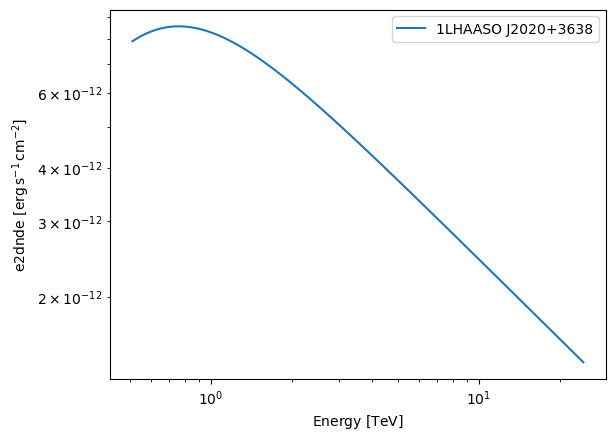

In [107]:
energy_bounds = [0.5, 25] * u.TeV
modelWCDA = PowerLawSpectralModel(
    index=2.62,
    amplitude="3.59e-13 TeV-1 cm-2 s-1",
    reference= 3* u.TeV,
)
model = SmoothBrokenPowerLawSpectralModel(
    index1=0.5,
    index2=2.62,
    amplitude="1.6e-11 TeV-1 cm-2 s-1",
    ebreak="0.5 TeV",
    reference="3 TeV",
    beta=1,
)

#energy= np.logspace(np.log10(1), np.log10(25), 200) * u.TeV

model.plot(energy_bounds, sed_type="e2dnde", label = "1LHAASO J2020+3638")
#modelWCDA.plot(energy_bounds, sed_type="e2dnde", label = "WCDA")
plt.legend()
import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "1LHAASOJ2020+3638.png"), dpi=300)
plt.show()

In [62]:
ra = 305.14 * u.deg
dec = 36.63* u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)

gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="1.27 deg")
gammacygni = SkyModel(spatial_model=gauss,  spectral_model=model, name="1LHAASO J2020+3638")
models = Models([gammacygni])

print(models.to_yaml())
models.write("1LHAASO J2020+3638.yaml", overwrite=True)

74.97943970433806 deg 0.07276539473867741 deg
components:
-   name: 1LHAASO J2020+3638
    type: SkyModel
    spectral:
        type: SmoothBrokenPowerLawSpectralModel
        parameters:
        -   name: index1
            value: 0.5
        -   name: index2
            value: 2.62
        -   name: amplitude
            value: 1.6e-11
            unit: TeV-1 s-1 cm-2
        -   name: ebreak
            value: 0.5
            unit: TeV
        -   name: reference
            value: 3.0
            unit: TeV
        -   name: beta
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 74.97943970433806
            unit: deg
        -   name: lat_0
            value: 0.07276539473867741
            unit: deg
        -   name: sigma
            value: 1.27
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
me

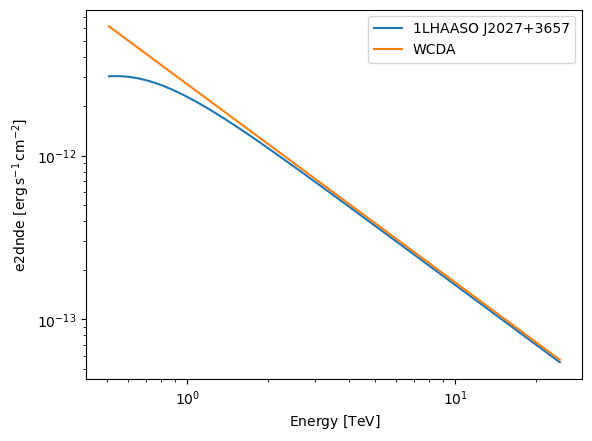

In [72]:
energy_bounds = [0.5, 25] * u.TeV
modelWCDA = PowerLawSpectralModel(
    index=3.21,
    amplitude="0.5e-13 TeV-1 cm-2 s-1",
    reference= 3* u.TeV,
)
model = SmoothBrokenPowerLawSpectralModel(
    index1=0.5,
    index2=3.21,
    amplitude="6.2e-12 TeV-1 cm-2 s-1",
    ebreak="0.5 TeV",
    reference="3 TeV",
    beta=1,
)
#energy= np.logspace(np.log10(1), np.log10(25), 200) * u.TeV

model.plot(energy_bounds, sed_type="e2dnde", label = "1LHAASO J2027+3657")
modelWCDA.plot(energy_bounds, sed_type="e2dnde", label = "WCDA")
plt.legend()

In [73]:
ra = 306.88 * u.deg
dec = 36.95* u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)

gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="0.38 deg")
gammacygni = SkyModel(spatial_model=gauss,  spectral_model=model, name="1LHAASO J2027+3657")
models = Models([gammacygni])

print(models.to_yaml())
models.write("1LHAASO J2027+3657.yaml", overwrite=True)

76.04220418783308 deg -0.8836146446558746 deg
components:
-   name: 1LHAASO J2027+3657
    type: SkyModel
    spectral:
        type: SmoothBrokenPowerLawSpectralModel
        parameters:
        -   name: index1
            value: 0.5
        -   name: index2
            value: 3.21
        -   name: amplitude
            value: 6.2e-12
            unit: TeV-1 s-1 cm-2
        -   name: ebreak
            value: 0.5
            unit: TeV
        -   name: reference
            value: 3.0
            unit: TeV
        -   name: beta
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 76.04220418783308
            unit: deg
        -   name: lat_0
            value: -0.8836146446558746
            unit: deg
        -   name: sigma
            value: 0.38
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
me

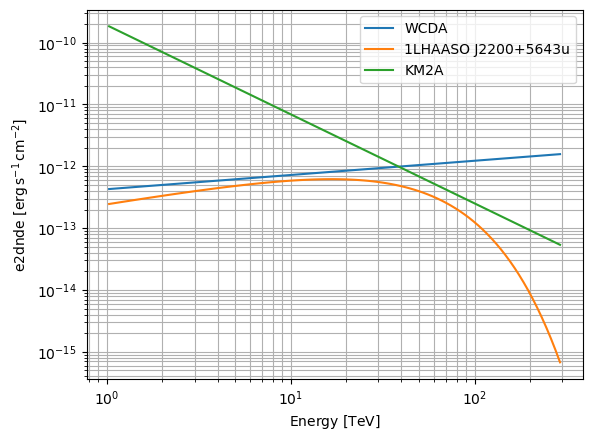

In [105]:
energy_bounds = [1,300] * u.TeV
modelWCDA = PowerLawSpectralModel(
    index=1.77,
    amplitude="0.38e-13 TeV-1 cm-2 s-1",
    reference= 3* u.TeV,
)


model = ExpCutoffPowerLawSpectralModel(
    amplitude=0.3e-13* u.Unit("cm-2 s-1 TeV-1"),
    index=1.5,
    lambda_=0.03 * u.Unit("TeV-1"),
    reference=3 * u.TeV,
)
modelKM2A = PowerLawSpectralModel(
    amplitude=1.70e-16* u.Unit("cm-2 s-1 TeV-1"),
    index=3.44,
    reference=50* u.TeV,
)
modelWCDA.plot(energy_bounds, sed_type="e2dnde", label = "WCDA")
model.plot(energy_bounds, sed_type="e2dnde", label = "1LHAASO J2200+5643u")
modelKM2A.plot(energy_bounds, sed_type="e2dnde", label = "KM2A")
plt.grid(which="both")
plt.legend()

In [106]:
ra = 330.38 * u.deg
dec = 56.73* u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)

gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="0.43 deg")
skymodel = SkyModel(spatial_model=gauss,  spectral_model=model, name="1LHAASO J2200+5643u")
models = Models([skymodel])

print(models.to_yaml())
models.write("1LHAASO J2200+5643u.yaml", overwrite=True)

101.18196248923437 deg 1.2126709165397025 deg
components:
-   name: 1LHAASO J2200+5643u
    type: SkyModel
    spectral:
        type: ExpCutoffPowerLawSpectralModel
        parameters:
        -   name: index
            value: 1.5
        -   name: amplitude
            value: 3.0e-14
            unit: TeV-1 s-1 cm-2
        -   name: reference
            value: 3.0
            unit: TeV
        -   name: lambda_
            value: 0.03
            unit: TeV-1
        -   name: alpha
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 101.18196248923437
            unit: deg
        -   name: lat_0
            value: 1.2126709165397025
            unit: deg
        -   name: sigma
            value: 0.43
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metadata:
    creator: Gammapy 2.0
    date: '202

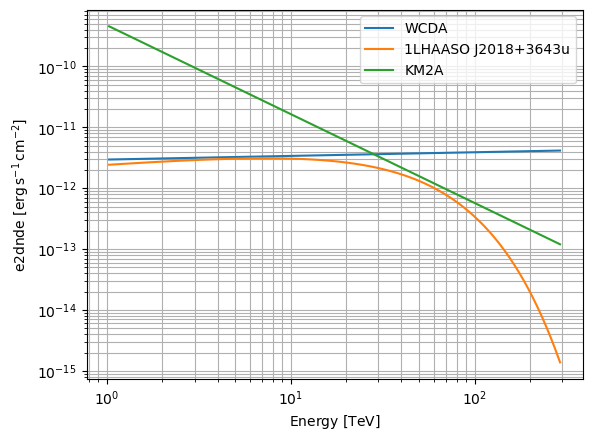

In [97]:
energy_bounds = [1, 300] * u.TeV
modelWCDA = PowerLawSpectralModel(
    index=1.94,
    amplitude="2.19e-13 TeV-1 cm-2 s-1",
    reference= 3* u.TeV,
)

#energy= np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


model = ExpCutoffPowerLawSpectralModel(
    amplitude=2.2e-13* u.Unit("cm-2 s-1 TeV-1"),
    index=1.78,
    lambda_=0.03 * u.Unit("TeV-1"),
    reference=3 * u.TeV,
)

modelKM2A = PowerLawSpectralModel(
    amplitude=3.93e-16* u.Unit("cm-2 s-1 TeV-1"),
    index=3.46,
    reference=50 * u.TeV,
)

modelWCDA.plot(energy_bounds, sed_type="e2dnde", label = "WCDA")
model.plot(energy_bounds, sed_type="e2dnde", label = "1LHAASO J2018+3643u")
modelKM2A.plot(energy_bounds, sed_type="e2dnde", label = "KM2A")
plt.grid(which="both")
#plt.ylim(1e-13,1e-12)
plt.legend()


In [98]:
ra = 304.61 * u.deg
dec = 36.75* u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)

gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="0.03 deg")
skymodel = SkyModel(spatial_model=gauss,  spectral_model=model, name="1LHAASO J2018+3643u")
models = Models([skymodel])

print(models.to_yaml())
models.write("1LHAASO J2018+3643u.yaml", overwrite=True)

74.83833395600777 deg 0.49122807479935143 deg
components:
-   name: 1LHAASO J2018+3643u
    type: SkyModel
    spectral:
        type: ExpCutoffPowerLawSpectralModel
        parameters:
        -   name: index
            value: 1.78
        -   name: amplitude
            value: 2.2e-13
            unit: TeV-1 s-1 cm-2
        -   name: reference
            value: 3.0
            unit: TeV
        -   name: lambda_
            value: 0.03
            unit: TeV-1
        -   name: alpha
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 74.83833395600777
            unit: deg
        -   name: lat_0
            value: 0.49122807479935143
            unit: deg
        -   name: sigma
            value: 0.03
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metadata:
    creator: Gammapy 2.0
    date: '20